CPU_benchmark_v4 mérete: (3825, 12)
CPU_r23_v2 mérete: (215, 9)
Tisztított adathalmaz mérete: (3825, 7)



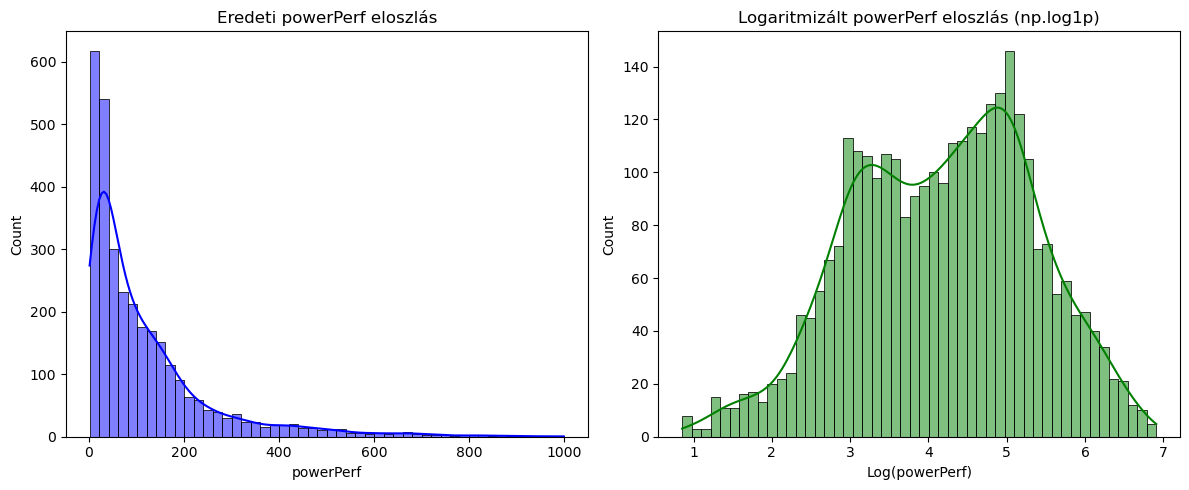

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Adatok betöltése
df1 = pd.read_csv('../data/raw/CPU_benchmark_v4.csv')
df2 = pd.read_csv('../data/raw/CPU_r23_v2.csv')

print(f"CPU_benchmark_v4 mérete: {df1.shape}")
print(f"CPU_r23_v2 mérete: {df2.shape}")

# 2. Adatszivárgás (Data Leakage) megszüntetése - csak df1-en
columns_to_drop = ['cpuName', 'cpuMark', 'TDP', 'cpuValue', 'threadValue']
df_cleaned = df1.drop(columns=columns_to_drop)

print(f"Tisztított adathalmaz mérete: {df_cleaned.shape}\n")

# 3. Célváltozó (powerPerf) eloszlásának vizsgálata vizuálisan
plt.figure(figsize=(12, 5))

# Eredeti eloszlás (Valószínűleg nagyon el lesz tolódva balra)
plt.subplot(1, 2, 1)
# Konvertáljuk numerikusra a 'powerPerf' oszlopot, mielőtt kezeljük a hiányzó értékeket
pp_series = pd.to_numeric(df_cleaned['powerPerf'], errors='coerce').dropna()
# pylint: disable=E1136  # type: ignore[call-arg]
# explicit x= argument helps pyright infer data source correctly
sns.histplot(x=pp_series, kde=True, bins=50, color='blue')
plt.title('Eredeti powerPerf eloszlás')
plt.xlabel('powerPerf')

# Logaritmizált eloszlás (np.log1p-t használunk, ami biztonságos 0 közeli értékeknél is)
plt.subplot(1, 2, 2)
log_pp = np.log1p(pp_series)
sns.histplot(x=log_pp, kde=True, bins=50, color='green')
plt.title('Logaritmizált powerPerf eloszlás (np.log1p)')
plt.xlabel('Log(powerPerf)')

plt.tight_layout()
plt.show()

In [5]:
# Hiányzó értékek és nullák száma oszloponként a nyers adatokban
print("CPU_benchmark_v4:")
for col in df1.columns:
    null_count = df1[col].isnull().sum()
    if pd.api.types.is_numeric_dtype(df1[col]):
        zero_count = (df1[col] == 0).sum()
        print(f"  {col}: hiányzók: {null_count}, nullák: {zero_count}")
    else:
        print(f"  {col}: hiányzók: {null_count}, nullák: N/A")
print("\nCPU_r23_v2:")
for col in df2.columns:
    null_count = df2[col].isnull().sum()
    if pd.api.types.is_numeric_dtype(df2[col]):
        zero_count = (df2[col] == 0).sum()
        print(f"  {col}: hiányzók: {null_count}, nullák: {zero_count}")
    else:
        print(f"  {col}: hiányzók: {null_count}, nullák: N/A")

CPU_benchmark_v4:
  cpuName: hiányzók: 0, nullák: N/A
  price: hiányzók: 1858, nullák: 0
  cpuMark: hiányzók: 0, nullák: 0
  cpuValue: hiányzók: 1858, nullák: 0
  threadMark: hiányzók: 0, nullák: 0
  threadValue: hiányzók: 1858, nullák: 0
  TDP: hiányzók: 685, nullák: 0
  powerPerf: hiányzók: 685, nullák: N/A
  cores: hiányzók: 0, nullák: 0
  testDate: hiányzók: 0, nullák: 0
  socket: hiányzók: 0, nullák: N/A
  category: hiányzók: 0, nullák: N/A

CPU_r23_v2:
  manufacturer: hiányzók: 0, nullák: N/A
  cpuName: hiányzók: 0, nullák: N/A
  singleScore: hiányzók: 0, nullák: 0
  multiScore: hiányzók: 0, nullák: 0
  cores: hiányzók: 0, nullák: 0
  threads: hiányzók: 0, nullák: 0
  baseClock: hiányzók: 0, nullák: 0
  turboClock: hiányzók: 0, nullák: 0
  type: hiányzók: 0, nullák: N/A


In [6]:
# Nézzük meg, melyik oszlopban mennyi hiányzó érték van
print("Hiányzó értékek száma oszloponként:")
print(df_cleaned.isnull().sum())

# Ellenőrizzük az adattípusokat (fontos: a price és a testDate valószínűleg object/string)
print("\nAdattípusok:")
print(df_cleaned.dtypes)

Hiányzó értékek száma oszloponként:
price         1858
threadMark       0
powerPerf      685
cores            0
testDate         0
socket           0
category         0
dtype: int64

Adattípusok:
price         float64
threadMark      int64
powerPerf         str
cores           int64
testDate        int64
socket            str
category          str
dtype: object
